In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [3]:
import os

dataset_path = "/kaggle/input/mnist-dataset"

for root, dirs, files in os.walk(dataset_path):
    print(root)
    print("Folders:", dirs[:5])
    print("Files:", files[:5])
    print("-"*50)

In [4]:
import os

print(os.listdir("/kaggle/input"))

['datasets']


In [5]:
import os

print(os.listdir("/kaggle/input/datasets"))

['awsaf49']


In [6]:
import os

print(os.listdir("/kaggle/input/datasets/awsaf49"))

['mnist-dataset']


In [7]:
import os

print(os.listdir("/kaggle/input/datasets/awsaf49/mnist-dataset"))

['mnist_png']


In [8]:
import os

print(os.listdir("/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png"))

['training', 'testing']


In [9]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(
    root="/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training",
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root="/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/testing",
    transform=transform
)

print("Training Images:", len(train_dataset))
print("Testing Images:", len(test_dataset))

Training Images: 60000
Testing Images: 10000


## Creating DataLoaders

The dataset is loaded in batches using PyTorch DataLoader. Shuffling is enabled for the training dataset to improve learning by presenting the images in a different order during every epoch.

In [10]:
import torch
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print(f"Training Batches : {len(train_loader)}")
print(f"Testing Batches  : {len(test_loader)}")

Training Batches : 469
Testing Batches  : 79


## Dataset Exploration

Before training the model, it is important to understand the dataset. This section displays the total number of images, available classes, image dimensions, and pixel value range after preprocessing.

In [11]:

print(f"Training Images : {len(train_dataset)}")
print(f"Testing Images  : {len(test_dataset)}")

print("\nDigit Classes:")
print(train_dataset.classes)

print(f"\nNumber of Classes : {len(train_dataset.classes)}")


images, labels = next(iter(train_loader))

print("\nImage Batch Shape :", images.shape)
print("Label Shape       :", labels.shape)

print("Image Data Type   :", images.dtype)

print("Pixel Value Range :", images.min().item(), "to", images.max().item())

Training Images : 60000
Testing Images  : 10000

Digit Classes:
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

Number of Classes : 10

Image Batch Shape : torch.Size([128, 1, 28, 28])
Label Shape       : torch.Size([128])
Image Data Type   : torch.float32
Pixel Value Range : 0.0 to 1.0


## Sample Images from the MNIST Dataset

Before adding noise and training the model, we visualize a few randomly selected images from the training dataset. This helps verify that the images have been loaded correctly and that the preprocessing pipeline is functioning as expected.

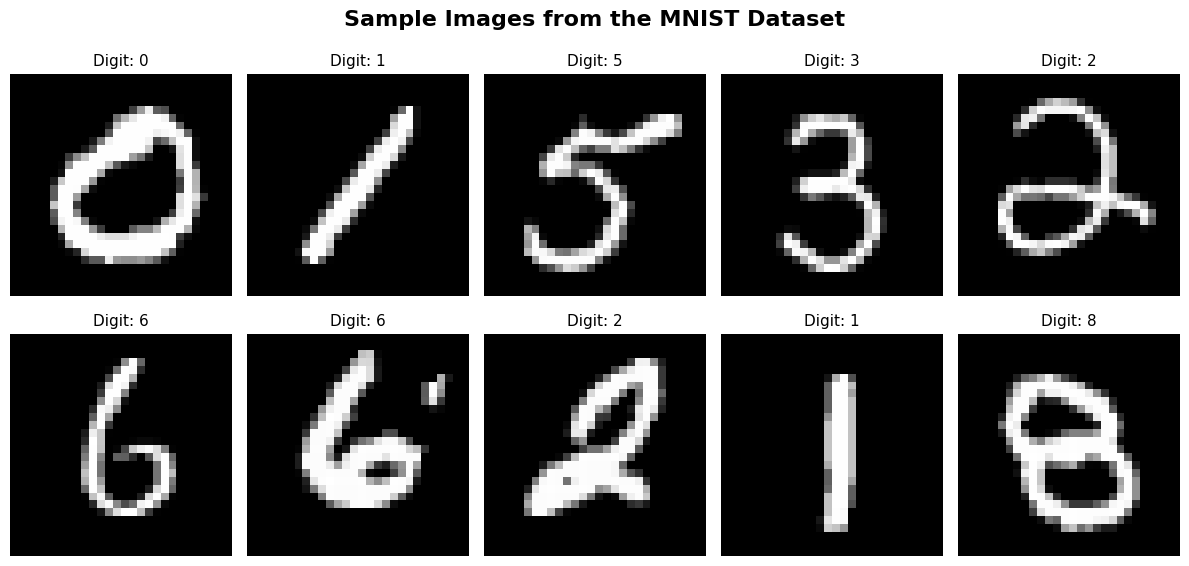

In [12]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

class_names = train_dataset.classes

plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(images[i].squeeze(), cmap="gray")

    plt.title(f"Digit: {class_names[labels[i]]}", fontsize=11)

    plt.axis("off")

plt.suptitle("Sample Images from the MNIST Dataset", fontsize=16, fontweight="bold")

plt.tight_layout()

plt.show()

## Gaussian Noise Generation

A Denoising Autoencoder is trained to reconstruct clean images from corrupted inputs. To simulate real-world image corruption, Gaussian noise is added to the original MNIST images. During training, the noisy images serve as inputs, while the corresponding clean images act as target outputs.

The noise is generated from a Gaussian (normal) distribution and the resulting pixel values are clipped to the valid range of **[0, 1]**.

In [13]:
NOISE_FACTOR = 0.4

def add_gaussian_noise(images, noise_factor=NOISE_FACTOR):
    
    noise = torch.randn_like(images)

    noisy_images = images + noise_factor * noise

    noisy_images = torch.clamp(noisy_images, 0., 1.)

    return noisy_images

## Original vs Noisy Images

The figure below compares the original handwritten digit images with their noisy counterparts. Although the digits remain recognizable, Gaussian noise introduces random pixel disturbances that make the reconstruction task more challenging.

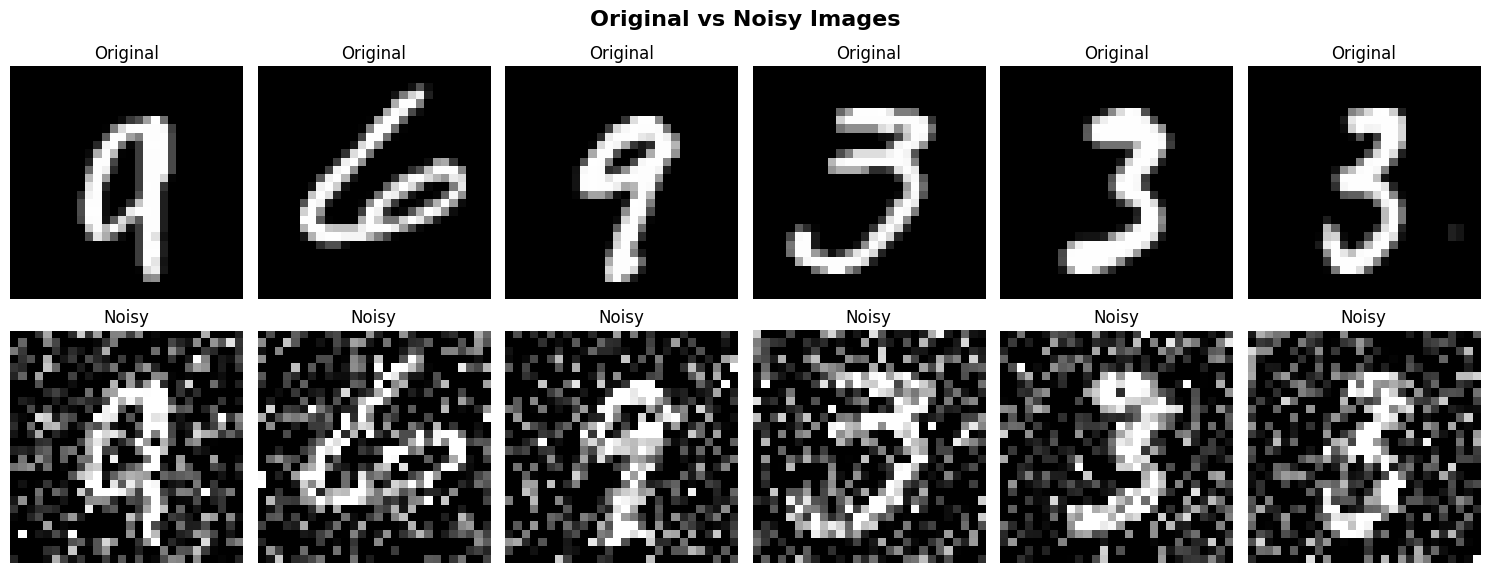

In [14]:
images, labels = next(iter(train_loader))

noisy_images = add_gaussian_noise(images)

plt.figure(figsize=(15,6))

for i in range(6):

    plt.subplot(2,6,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2,6,i+7)
    plt.imshow(noisy_images[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

plt.suptitle("Original vs Noisy Images", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

# Build the Denoising Autoencoder

A Convolutional Autoencoder consists of two main components:

- **Encoder:** Compresses the noisy input image into a compact latent representation by extracting meaningful features.
- **Decoder:** Reconstructs the original clean image from the latent representation.

Convolutional layers are used instead of fully connected layers because they preserve the spatial structure of images, making them more effective for image denoising tasks.

In [15]:
import torch.nn as nn

class DenoisingAutoencoder(nn.Module):

    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        self.encoder = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.MaxPool2d(2,2),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.MaxPool2d(2,2)
        )


        self.decoder = nn.Sequential(


            nn.ConvTranspose2d(
                in_channels=64,
                out_channels=32,
                kernel_size=2,
                stride=2
            ),
            nn.ReLU(),

            nn.ConvTranspose2d(
                in_channels=32,
                out_channels=1,
                kernel_size=2,
                stride=2
            ),

            nn.Sigmoid()
        )

    def forward(self, x):

        encoded = self.encoder(x)

        decoded = self.decoder(encoded)

        return decoded

## Model Initialization

After defining the architecture, the model is instantiated and moved to the available device (GPU if available, otherwise CPU).

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

model = DenoisingAutoencoder().to(device)

print(model)

Using Device: cpu
DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(32, 1, kernel_size=(2, 2), stride=(2, 2))
    (3): Sigmoid()
  )
)


In [17]:

total_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(f"Total Trainable Parameters: {total_params:,}")

Total Trainable Parameters: 27,169


# Model Training Configuration

The denoising autoencoder is trained using Mean Squared Error (MSE) loss because image reconstruction is a regression task. The Adam optimizer is used for efficient gradient-based optimization.

In [18]:
import torch.optim as optim

LEARNING_RATE = 0.001
EPOCHS = 20

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Loss Function :", criterion)
print("Optimizer     :", optimizer.__class__.__name__)
print("Learning Rate :", LEARNING_RATE)
print("Epochs        :", EPOCHS)

Loss Function : MSELoss()
Optimizer     : Adam
Learning Rate : 0.001
Epochs        : 20


## Validation Function

During validation, the model is evaluated on unseen test images without updating the model parameters. This helps monitor the reconstruction performance after each training epoch.

In [19]:
def validate_one_epoch(model, dataloader, criterion, device):

    model.eval()

    running_loss = 0.0

    with torch.no_grad():

        for images, _ in dataloader:

            images = images.to(device)

            noisy_images = add_gaussian_noise(images)

            outputs = model(noisy_images)

            loss = criterion(outputs, images)

            running_loss += loss.item()

    epoch_loss = running_loss / len(dataloader)

    return epoch_loss

## Model Training

The model is trained using noisy images as input and clean images as targets. Training and validation losses are recorded after every epoch to monitor convergence.

In [22]:
def train_model(model,
                train_loader,
                test_loader,
                criterion,
                optimizer,
                epochs,
                device):

    train_losses = []
    validation_losses = []

    for epoch in range(epochs):

        model.train()

        train_loss = 0.0

        for images, _ in train_loader:

            images = images.to(device)

            noisy_images = add_gaussian_noise(images)

            optimizer.zero_grad()

            outputs = model(noisy_images)

            loss = criterion(outputs, images)

            loss.backward()

            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        model.eval()

        validation_loss = 0.0

        with torch.no_grad():

            for images, _ in test_loader:

                images = images.to(device)

                noisy_images = add_gaussian_noise(images)

                outputs = model(noisy_images)

                loss = criterion(outputs, images)

                validation_loss += loss.item()

        validation_loss /= len(test_loader)

        train_losses.append(train_loss)
        validation_losses.append(validation_loss)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"| Train Loss: {train_loss:.6f} "
            f"| Validation Loss: {validation_loss:.6f}"
        )

    return train_losses, validation_losses

In [23]:
train_losses, validation_losses = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=EPOCHS,
    device=device
)

Epoch [1/20] | Train Loss: 0.028186 | Validation Loss: 0.012653
Epoch [2/20] | Train Loss: 0.011816 | Validation Loss: 0.011002
Epoch [3/20] | Train Loss: 0.010849 | Validation Loss: 0.010501
Epoch [4/20] | Train Loss: 0.010436 | Validation Loss: 0.010178
Epoch [5/20] | Train Loss: 0.010176 | Validation Loss: 0.009955
Epoch [6/20] | Train Loss: 0.009975 | Validation Loss: 0.009803
Epoch [7/20] | Train Loss: 0.009810 | Validation Loss: 0.009669
Epoch [8/20] | Train Loss: 0.009691 | Validation Loss: 0.009480
Epoch [9/20] | Train Loss: 0.009556 | Validation Loss: 0.009363
Epoch [10/20] | Train Loss: 0.009447 | Validation Loss: 0.009310
Epoch [11/20] | Train Loss: 0.009362 | Validation Loss: 0.009191
Epoch [12/20] | Train Loss: 0.009282 | Validation Loss: 0.009199
Epoch [13/20] | Train Loss: 0.009235 | Validation Loss: 0.009093
Epoch [14/20] | Train Loss: 0.009176 | Validation Loss: 0.009008
Epoch [15/20] | Train Loss: 0.009133 | Validation Loss: 0.008971
Epoch [16/20] | Train Loss: 0.0090

## Training and Validation Loss

The following graph shows the training and validation loss across all epochs. A decreasing loss indicates that the autoencoder is learning to reconstruct clean images from noisy inputs.

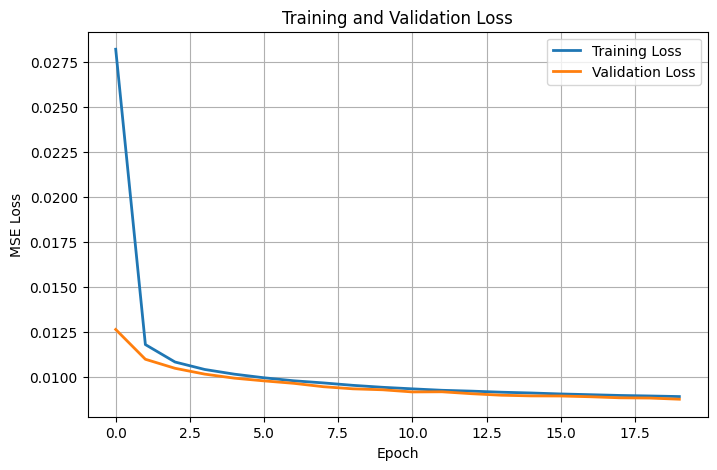

In [27]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss", linewidth=2)
plt.plot(validation_losses, label="Validation Loss", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

## Image Reconstruction

The trained autoencoder is used to reconstruct clean images from noisy inputs. The following section generates denoised images from the test dataset.

In [25]:
model.eval()

images, labels = next(iter(test_loader))

images = images.to(device)

noisy_images = add_gaussian_noise(images)

with torch.no_grad():
    reconstructed_images = model(noisy_images)

images = images.cpu()
noisy_images = noisy_images.cpu()
reconstructed_images = reconstructed_images.cpu()

## Original vs Noisy vs Denoised Images

The figure below compares the original handwritten digits, their noisy versions, and the reconstructed images produced by the denoising autoencoder.

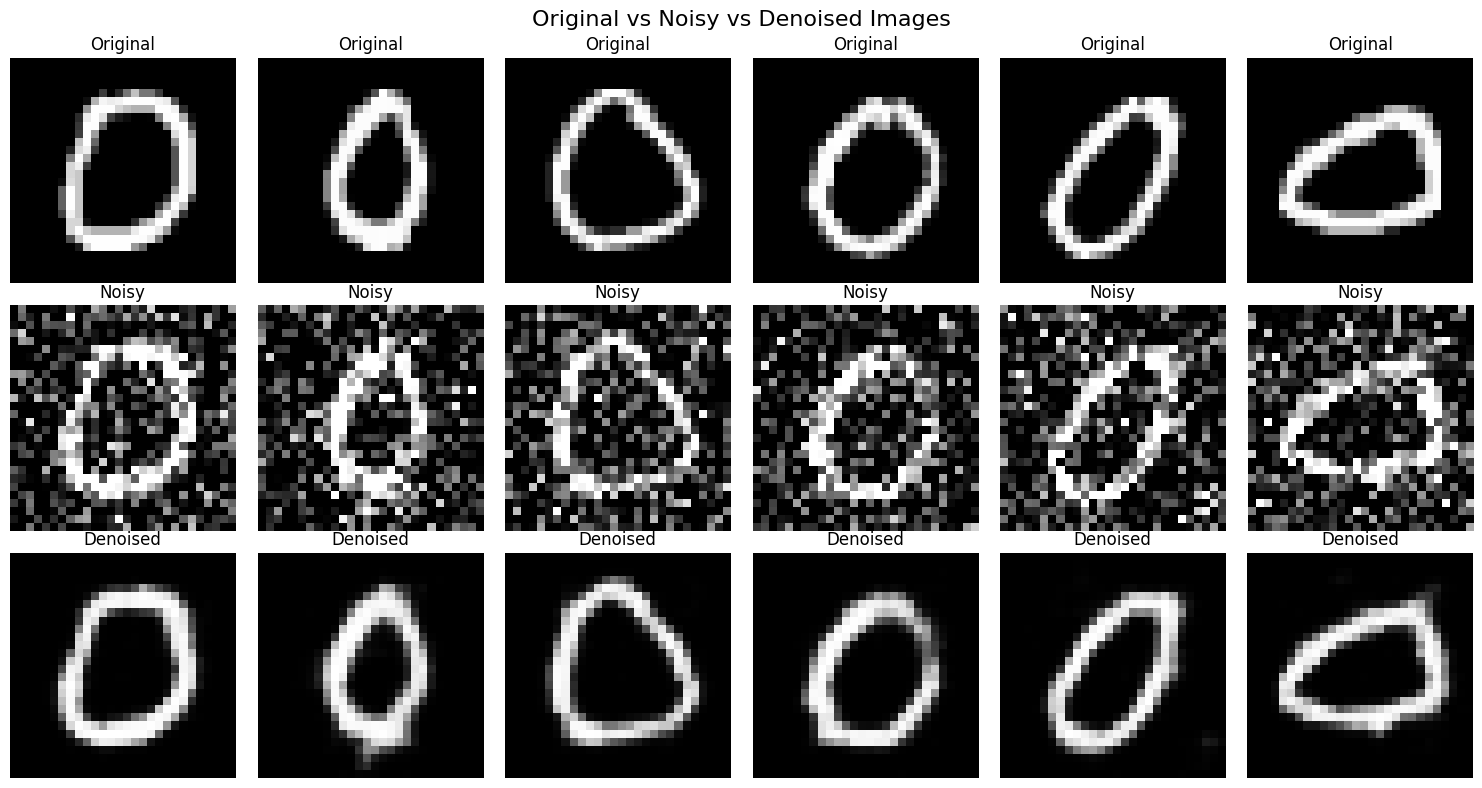

In [26]:
num_images = 6

plt.figure(figsize=(15,8))

for i in range(num_images):

    plt.subplot(3, num_images, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(3, num_images, i + 1 + num_images)
    plt.imshow(noisy_images[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    plt.subplot(3, num_images, i + 1 + (2 * num_images))
    plt.imshow(reconstructed_images[i].squeeze(), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.suptitle("Original vs Noisy vs Denoised Images", fontsize=16)

plt.tight_layout()

plt.show()

# Model Evaluation

The performance of the denoising autoencoder is evaluated using **Mean Squared Error (MSE)** and **Peak Signal-to-Noise Ratio (PSNR)**.

- **MSE (Mean Squared Error):** Measures the average squared difference between the reconstructed image and the original image. Lower values indicate better reconstruction.
- **PSNR (Peak Signal-to-Noise Ratio):** Measures the reconstruction quality in decibels (dB). Higher values indicate better image quality.

In [28]:
import numpy as np

mse = torch.mean((reconstructed_images - images) ** 2).item()

print(f"Test MSE : {mse:.6f}")

Test MSE : 0.009414


In [29]:
def calculate_psnr(mse):

    if mse == 0:
        return float("inf")

    return 20 * np.log10(1.0 / np.sqrt(mse))

psnr = calculate_psnr(mse)

print(f"PSNR : {psnr:.2f} dB")

PSNR : 20.26 dB


In [30]:
!pip install scikit-image -q

In [31]:
from skimage.metrics import structural_similarity as ssim

img1 = images[0].squeeze().numpy()
img2 = reconstructed_images[0].squeeze().numpy()

score = ssim(img1, img2, data_range=1.0)

print(f"SSIM : {score:.4f}")

SSIM : 0.9149


# Observations

- The convolutional denoising autoencoder successfully learned to reconstruct clean handwritten digit images from noisy inputs.
- Both the training and validation losses decreased steadily during training, indicating effective learning.
- The reconstructed images preserved the overall digit structure while removing a significant portion of the Gaussian noise.
- Some reconstructed digits appeared slightly blurred because the model optimized the average reconstruction error rather than preserving every fine detail.
- The calculated MSE and PSNR values indicate good reconstruction quality.
- The model generalized well to unseen test images, demonstrating its ability to perform image denoising.

# Conclusion

In this project, a Convolutional Denoising Autoencoder was implemented using the MNIST handwritten digit dataset.

Artificial Gaussian noise was added to clean images, and the model was trained to reconstruct the original images from their noisy versions.

The trained autoencoder successfully removed most of the noise while preserving the essential structure of the handwritten digits. Both qualitative visualization and quantitative evaluation using MSE and PSNR demonstrated the effectiveness of the proposed approach.

This project illustrates the capability of autoencoders for image restoration and forms a strong foundation for more advanced applications such as medical image denoising, image super-resolution, and image inpainting.